# 056 — Post-process the cyclic pushover and modal analyses

Notebook `055` wrote a FEMA 461 cyclic pushover (CPO) and a modal analysis for each of the **51 design groups**
(25 x 3-storey, 26 x 5-storey); they run on the analysis machine. This notebook reduces their raw output to the
structural properties nb `072` needs as regression covariates, and writes

`data_processed/08_casestudy_structure_datasets/design_group_structure_properties.csv`.

Until that file exists nb `072` falls back to **dummy constants** ($\Omega = 1.5$, $\mu = 1.7$) and sets
`pushover_is_dummy = True`. Those dummies are constant across all 51 designs, so `ln_overstrength` and
`ln_ductility` carry no information at all. Writing this file is what turns them into real covariates.

## What is computed

| quantity | symbol | how |
|---|---|---|
| peak base shear | $V_{max}$ | peak of the fitted **envelope** |
| overstrength | $\Omega = V_{max}/V_b$ | $V_b$ = `design_baseshear` of the group's representative design |
| yield displacement (backbone) | $\delta_{y}$ | yield breakpoint of the idealised CBF backbone |
| yield displacement (P695) | $\delta_{y,eff}$ | FEMA P695 Eq. 6-7, with $C_0$ from Eq. 6-8 |
| fracture displacement | $d_f$ | start of the steep drop caused by brace fracture |
| ultimate displacement | $\delta_u$ | envelope has fallen to $0.8\,V_{max}$ after the peak |
| period | $T_1$ | `eigenPeriod[0]` of the modal analysis |

Four ductilities follow from the two yield definitions crossed with the two target displacements
($d_f$ and $\delta_u$). `DUCTILITY_DEF` in §0 selects which one is exported to nb `072`.

## Three things worth knowing before reading the numbers

**1. $V_{max}$ comes from the envelope, not from the idealised backbone.** `fitpo.fit_cbf_backbone` places its
yield point where the idealised *elastic line* meets the post-buckling branch. That intersection can sit well above
any force the structure actually carried — on `group_3s_00` it lands at 734 kN against an envelope peak of 442 kN,
which would report $\Omega = 8.4$ instead of 5.05. The backbone's $f_y$ is still carried, as `omega_y`, and
`backbone_overshoots_envelope` flags the designs where the idealisation has run away from the data.

**2. The envelope mode is `loading-front`, not `peak-to-peak`.** `fit_cbf_backbone` locates the brace fracture with
a CUSUM change detector on the force gradient, and CUSUM needs enough samples to estimate a baseline. The
`peak-to-peak` envelope of these runs has only 11–18 breakpoints, and the detector fails on every one of them with
*"No fracture detected by CUSUM"* even where the drop is a blatant 497 kN → 94 kN. The `loading-front` envelope —
every point whose $|d|$ exceeds all earlier points, i.e. literally *"the peak base shear reached at each new
displacement excursion"*, which is how nb `055` defines the envelope — has ~1700 points and fits cleanly.

**3. Several CPOs stop before the full $\pm$6 % roof-drift trace.** They are kept and flagged, never extrapolated;
quantities a truncated trace cannot support come out as `NaN`. §2 prints the review list.

## Outputs

| path | what |
|---|---|
| `results/08_group_cpo/{design_group_id}_cpo.png` | one reviewable figure per design |
| `results/08_group_cpo/cpo_overview_{n}s.png` | contact sheets for scanning all 51 |
| `data_processed/08_casestudy_structure_datasets/design_group_cpo_modal_properties.csv` | everything computed |
| `data_processed/08_casestudy_structure_datasets/design_group_structure_properties.csv` | the trimmed frame nb `072` asserts on |


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import warnings
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from fitpo import fit_envelope, fit_tetralinear_backbone

from phd_project.config import config
from phd_project.scripts import cache_utils
from phd_project.scripts import cpo_postprocessing as cpp
from phd_project.scripts.cpo_du import existing_cpo_du
from phd_project.scripts.loading_protocols import get_FEMA461_displacements_for_building
from phd_project.scripts.WP1_ground_motion_set.design_groups import load_design_groups

cfg = config.load_config()

## 0. Parameters

`RESULTS_ROOT` is the analysis tree nb `055` wrote into. Point it at the sample folder to develop against the few
groups that have been copied off the analysis machine; the full run needs the drive attached.

In [3]:
# -----------------------------------------------------------------------------
# WHERE THE ANALYSES ARE
# -----------------------------------------------------------------------------
# The group tree nb 055 wrote: RESULTS_ROOT/group_{n}s_{gid:02d}/{n}s/mdof/
RESULTS_ROOT = Path(cfg["analysis_data"]["wp1_fixed_record_sets"])

# Develop against the sample copy instead. Set to None to use RESULTS_ROOT.
# Groups whose po_curve.csv is missing are skipped with a warning, so either
# root runs end to end.
SAMPLE_ROOT = Path(r"C:\Users\clemettn\Desktop\test_folder")
if SAMPLE_ROOT is not None and SAMPLE_ROOT.is_dir():
    RESULTS_ROOT = SAMPLE_ROOT

# The site-specific designs from nb 011; each group uses its representative's.
DESIGN_ROOT = Path(cfg["models"]["casestudy_designs_site_specific"])

CPO_RESULTS, MODAL_RESULTS = "cyclic_pushover", "modal"   # as nb 055

# -----------------------------------------------------------------------------
# ENVELOPE
# -----------------------------------------------------------------------------
ENVELOPE_MODE = "adjusted-peak-to-peak"

# Every usable envelope runs on into negative force once the braces have gone
# (-16 % of Fmax on the 3-storeys, -56 % on group_5s_06). That tail is not part
# of a backbone and only gives the area fit something meaningless to chase.
TRUNCATE_AT_ZERO_FORCE = True

# Shape-preserving resample: points are inserted ALONG the segments, so the
# curve is unchanged (area identical to 4.5e-16) but the knot search has finer
# positions to choose from - the fracture cliff is often a single segment.
RESAMPLE_ENVELOPE = True
RESAMPLE_DF_FRAC, RESAMPLE_DD_MM = 0.01, 10.0

# -----------------------------------------------------------------------------
# BACKBONE FIT
# -----------------------------------------------------------------------------
# The backbone is fitpo's tetralinear one, with its two interior knots chosen
# per curve to minimise the absolute area between envelope and backbone over
# [0, d(FIT_WINDOW_FRACTION * Fmax)].
#
# The knots are addressed by DISPLACEMENT, not by fitpo's force fractions. The
# fraction interface resolves a fraction as "first data point at or below
# fraction * Fmax", which is not monotone in the sampling of the curve: adding
# points can make the best achievable fit worse. By displacement the objective
# is continuous (surface checked) and a finer search can only help.
FIT_WINDOW_FRACTION = 0.5
KNOT_GRID_N = 20        # coarse-stage candidates per axis; cost ~ N(N-1)/2 fits
REFINE = True           # Nelder-Mead polish from the coarse winner

# design_group_id -> (d_f_mm, d_r_mm). Pins the knots for a curve whose
# automatic fit you reject on review. Physical units, unlike force fractions.
KNOT_OVERRIDES: dict[str, tuple[float, float]] = {}

# -----------------------------------------------------------------------------
# DEFINITIONS
# -----------------------------------------------------------------------------
# Which ductility nb 072 gets. The four are {yield definition} x {target}:
#   mu_f_bb    d_f    / d_y        backbone yield, fracture displacement
#   mu_u_bb    d_u    / d_y        backbone yield, 0.8 V_max displacement
#   mu_f_p695  d_f    / d_y,eff    FEMA P695 yield, fracture displacement
#   mu_u_p695  d_u    / d_y,eff    FEMA P695 yield, 0.8 V_max  <- P695's own mu_T
DUCTILITY_DEF = "mu_u_p695"

# Period fed to FEMA P695 Eq. 6-7. P695 says max(T_code, T1); we use the modal
# T1 and carry the strict variant alongside as a diagnostic - see section 3.
P695_PERIOD = "T1_modal"          # "T1_modal" | "max_code_T1"

# FEMA 461 protocol, as nb 055 wrote it. Needed to know what a complete run is.
CPO_MAX_DRIFT, CPO_N_STEPS, CPO_DU = 6.0, 12, 0.2

# Normalised area error above which a fit is put on the review list. The sample
# curves sit at 0.018-0.024, so this flags roughly a doubling of typical error.
AREA_ERROR_REVIEW = 0.05

STOREYS = [3, 5]
N_GROUPS_EXPECTED = 51

# -----------------------------------------------------------------------------
# OUTPUTS
# -----------------------------------------------------------------------------
FIG_PTH = Path(cfg["results"]["group_cpo"])
OUT_PTH = Path(cfg["proc_data"]["unique_structural_designs_csv"]).parent
FIG_PTH.mkdir(parents=True, exist_ok=True)

FULL_CSV = OUT_PTH / "design_group_cpo_modal_properties.csv"
PROPS_CSV = OUT_PTH / "design_group_structure_properties.csv"
COLDICT_CSV = OUT_PTH / "design_group_structure_properties_columns.csv"

# Envelopes and backbones are cached per design group: the knot search costs
# ~20-35 s a curve, far too slow to sit behind the plotting and table cells.
# The cache invalidates itself when po_curve.csv or any fitting parameter above
# changes (they are all fingerprinted); this forces a rebuild regardless.
FORCE_REFIT = False
FIT_CACHE_PTH = OUT_PTH / "cpo_backbone_fits"
FIT_CACHE_PTH.mkdir(parents=True, exist_ok=True)

DPI = 200

print(f"reading   {RESULTS_ROOT}")
print(f"figures   {FIG_PTH}")
print(f"tables    {OUT_PTH}")
print(f"fit cache {FIT_CACHE_PTH}  (force refit: {FORCE_REFIT})")

reading   C:\Users\clemettn\Desktop\test_folder
figures   C:\Users\clemettn\Documents\phd\results\08_group_cpo
tables    C:\Users\clemettn\Documents\phd\data_processed\08_casestudy_structure_datasets
fit cache C:\Users\clemettn\Documents\phd\data_processed\08_casestudy_structure_datasets\cpo_backbone_fits  (force refit: False)


## 1. Harvest

One row per design group. `design_group_id` = `group_{n}s_{gid:02d}` is the folder name nb `055` used *and* the
key nb `072` merges on, so it is carried unchanged.

In [4]:
groups_df = load_design_groups(cfg)
groups = (groups_df[groups_df["is_representative"] & groups_df["storeys"].isin(STOREYS)]
          .loc[:, ["storeys", "group_id", "representative_site", "representative_tag", "n_sites_in_group"]]
          .sort_values(["storeys", "group_id"])
          .reset_index(drop=True))
assert len(groups) == N_GROUPS_EXPECTED, f"{len(groups)} design groups, expected {N_GROUPS_EXPECTED}"


def group_folder_name(n: int, gid: int) -> str:
    # group_3s_00, ... - identical to nb 055; this IS nb 072's design_group_id.
    return f"group_{n}s_{int(gid):02d}"


def mdof_folder(n: int, gid: int) -> Path:
    return RESULTS_ROOT / group_folder_name(n, gid) / f"{n}s" / "mdof"


def design_file(tag: str) -> Path:
    return DESIGN_ROOT / tag / f"{tag}_out.json"


print(groups.groupby("storeys").size().to_string())
groups.head()

storeys
3    25
5    26


,storeys,group_id,representative_site,representative_tag,n_sites_in_group
0,3,0,0,3s_cbf_dc2_site0,8
1,3,1,1,3s_cbf_dc2_site1,6
2,3,2,3,3s_cbf_dc2_site3,1
3,3,3,7,3s_cbf_dc2_site7,5
4,3,4,9,3s_cbf_dc2_site9,3


### 1.1 Reduce one design

Everything about one group, in one function, so the loop below stays readable and a single design can be
re-run by hand while tuning `CBF_OVERRIDES`.

The backbone fit is allowed to fail: `fit_cbf_backbone` raises `ValueError` when its CUSUM detector finds no
fracture, or when the peak is the last point of the curve (a run that stopped while still climbing). Both are
real states of these analyses, not bugs, so the exception is recorded in `backbone_fit_error` and the row
survives with `NaN`s rather than killing the loop.

In [5]:
def fit_geometry(gname: str, mdof: Path) -> dict:
    """Envelope and fitted backbone for one group, cached on disk.

    This is the expensive half of the reduction - the knot search runs a few
    hundred backbone fits - so it is cached per design group with the repo's
    provenance-aware helper. Everything derived from it (backbone_metrics,
    overstrength, the ductilities) is milliseconds and is deliberately NOT
    cached, so adding a column to the results table costs nothing instead of
    invalidating every fit.

    cache_utils.fingerprint hashes po_curve.csv by content, so re-running an
    analysis invalidates its own entry; every fitting parameter is fingerprinted
    alongside it, so changing one rebuilds exactly what it should.
    """
    fp = cache_utils.fingerprint(
        po_curve=mdof / CPO_RESULTS / "po_curve.csv",
        envelope_mode=ENVELOPE_MODE,
        truncate=TRUNCATE_AT_ZERO_FORCE,
        resample=(RESAMPLE_ENVELOPE, RESAMPLE_DF_FRAC, RESAMPLE_DD_MM),
        window_fraction=FIT_WINDOW_FRACTION,
        search=(KNOT_GRID_N, REFINE),
        knots=KNOT_OVERRIDES.get(gname),
    )

    def compute() -> dict:
        cpo = cpp.load_cpo_curve(mdof, CPO_RESULTS)
        env_raw, _ = fit_envelope(cpo, mode=ENVELOPE_MODE)      # positive branch
        env = cpp.truncate_envelope_at_zero(env_raw) if TRUNCATE_AT_ZERO_FORCE else env_raw
        truncated = len(env) != len(env_raw)

        v_max, _ = cpp.envelope_peak_force(env)
        if RESAMPLE_ENVELOPE:
            env = cpp.resample_envelope(env, RESAMPLE_DF_FRAC * v_max, RESAMPLE_DD_MM)

        d_hi, rule = cpp.fit_window(env, FIT_WINDOW_FRACTION)
        out = {"envelope": env, "envelope_truncated": truncated,
               "fit_window_d_hi_mm": d_hi, "fit_window_rule": rule}
        try:
            out["fit"] = cpp.fit_tetralinear_optimised(
                env, d_hi=d_hi, grid_n=KNOT_GRID_N, refine=REFINE,
                knots=KNOT_OVERRIDES.get(gname))
            out["error"] = ""
        except ValueError as exc:
            # A curve with no usable descending branch. Flagged, never faked.
            out["fit"], out["error"] = None, str(exc)
        return out

    return cache_utils.load_or_compute(
        FIT_CACHE_PTH / f"{gname}_fit.pickle", fp, compute, force_recompute=FORCE_REFIT)


def reduce_design(n_storeys: int, gid: int, tag: str) -> tuple[dict, np.ndarray, dict]:
    """Every reported quantity for one design group."""
    gname = group_folder_name(n_storeys, gid)
    mdof = mdof_folder(n_storeys, gid)

    dq = cpp.load_design_quantities(design_file(tag))
    row = {
        "design_group_id": gname,
        "n_storeys": n_storeys,
        "group_id": int(gid),
        "representative_tag": tag,
        "Vb_design_N": dq["Vb_design_N"],
        "W_N": dq["W_N"],
        "seismic_mass_kg": dq["seismic_mass_kg"],
        "roof_height_mm": dq["roof_height_mm"],
        "design_period_s": dq["design_period_s"],
    }

    # --- modal ---------------------------------------------------------------
    modal = cpp.load_modal_properties(mdof, MODAL_RESULTS)
    periods = modal["eigenPeriod"]
    row["T1_modal_s"] = float(periods[0])
    row["T2_modal_s"] = float(periods[1]) if len(periods) > 1 else np.nan
    phi = cpp.first_mode_translational(mdof, dq["n_levels"], MODAL_RESULTS)
    row["C0"] = cpp.fema_C0(dq["storey_masses_kg"], phi)

    # --- envelope + backbone (cached) ----------------------------------------
    geom = fit_geometry(gname, mdof)
    envelope = geom["envelope"]
    row["envelope_n_points"] = len(envelope)
    row["envelope_truncated"] = geom["envelope_truncated"]
    row["fit_window_d_hi_mm"] = geom["fit_window_d_hi_mm"]
    row["fit_window_rule"] = geom["fit_window_rule"]

    v_max, d_at_v_max = cpp.envelope_peak_force(envelope)
    row["V_max_N"] = v_max
    row["d_at_V_max_mm"] = d_at_v_max

    # --- did the analysis finish? --------------------------------------------
    # The dU actually used, if the folder's config was tuned; else the default.
    cpo = cpp.load_cpo_curve(mdof, CPO_RESULTS)
    du = existing_cpo_du(mdof / "config_cyclic_pushover.py") or CPO_DU
    targets = get_FEMA461_displacements_for_building(
        design_file(tag), CPO_N_STEPS,
        U_max=None if CPO_MAX_DRIFT is None else CPO_MAX_DRIFT / 100 * dq["roof_height_mm"])
    row.update(cpp.cpo_completeness(cpo[:, 0], targets, du=du))

    # delta_u measured on the raw envelope, kept as a cross-check on the value
    # the backbone gives below.
    row["delta_u_env_mm"] = cpp.displacement_at_strength_loss(envelope, v_max)
    row["envelope_reaches_08fmax"] = bool(np.isfinite(row["delta_u_env_mm"]))

    # --- the fitted backbone --------------------------------------------------
    fit, backbone = geom["fit"], None
    if fit is not None:
        backbone = fit["backbone"]
        row["backbone_fit_ok"], row["backbone_fit_error"] = True, ""
        row.update(cpp.backbone_metrics(backbone))
        row["backbone_overshoots"] = cpp.backbone_overshoots_envelope(row["f_y_N"], v_max)
        for key in ("d_f_mm", "d_r_mm", "joint_force_fraction", "residual_force_fraction",
                    "fit_area_error", "fit_area_error_norm", "n_knot_candidates",
                    "fit_stage", "knot_on_bound"):
            row[key] = fit[key]
        # delta_u from the BACKBONE now that the idealisation is trustworthy.
        row["delta_u_mm"] = cpp.displacement_at_strength_loss(backbone, v_max)
    else:
        row["backbone_fit_ok"], row["backbone_fit_error"] = False, geom["error"]
        for key in ("d_y_mm", "f_y_N", "d_f_mm", "f_f_N", "f_max_bb_N", "d_max_mm",
                    "k_e_N_per_mm", "k_pb_N_per_mm", "k_r_N_per_mm", "d_r_mm",
                    "joint_force_fraction", "residual_force_fraction",
                    "fit_area_error", "fit_area_error_norm", "delta_u_mm"):
            row[key] = np.nan
        row["n_knot_candidates"] = 0
        row["fit_stage"] = "failed"
        row["backbone_overshoots"] = False
        row["knot_on_bound"] = False

    # --- FEMA P695 effective yield displacement -------------------------------
    # Eq. 6-7 with the modal T1 (reported), and with the strict max(T_code, T1)
    # the standard asks for (diagnostic) - see section 3.
    row["delta_y_eff_mm"] = cpp.delta_y_eff_p695(row["C0"], v_max, dq["W_N"], row["T1_modal_s"])
    period_strict = max(dq["design_period_s"], row["T1_modal_s"])
    row["delta_y_eff_maxT_mm"] = cpp.delta_y_eff_p695(row["C0"], v_max, dq["W_N"], period_strict)
    row["p695_period_used_s"] = row["T1_modal_s"] if P695_PERIOD == "T1_modal" else period_strict

    # --- overstrength and the four ductilities --------------------------------
    row["omega_max"] = v_max / dq["Vb_design_N"]
    row["omega_y"] = row["f_y_N"] / dq["Vb_design_N"]

    d_f, d_u = row["d_f_mm"], row["delta_u_mm"]
    row["mu_f_bb"] = d_f / row["d_y_mm"]
    row["mu_u_bb"] = d_u / row["d_y_mm"]
    row["mu_f_p695"] = d_f / row["delta_y_eff_mm"]
    row["mu_u_p695"] = d_u / row["delta_y_eff_mm"]
    row["mu_u_p695_maxT"] = d_u / row["delta_y_eff_maxT_mm"]

    return row, cpo, geom

In [6]:
############# TRIAL CELL ######################
folder = Path(r"D:\08_wp1_fixed_record_sets\group_3s_06\3s\mdof")
cpo = cpp.load_cpo_curve(folder, CPO_RESULTS)

# env_mode = "peak-to-peak"
env_mode = "adjusted-peak-to-peak"
# env_mode = "simplified-loading-front"
# env_mode = "loading-front"

envelope, _ = fit_envelope(cpo, mode=env_mode)
v_max, d_at_v_max = cpp.envelope_peak_force(envelope)
bb = fit_tetralinear_backbone(envelope, joint_force_fraction=0.99, residual_force_fraction=0.25, collapse_residual=False)

############# TRIAL CELL ######################
fig, ax = plt.subplots()
ax.plot(cpo[:, 0], cpo[:, 1], color="0.4")
ax.plot(envelope[:, 0], envelope[:, 1], color="r")
ax.plot(bb[:, 0], bb[:, 1], color="b")

FileNotFoundError: D:\08_wp1_fixed_record_sets\group_3s_06\3s\mdof\cyclic_pushover\po_curve.csv not found.

In [7]:
############# TRIAL CELL ######################
folder = Path(r"D:\08_wp1_fixed_record_sets\group_3s_03\3s\mdof")
cpo = cpp.load_cpo_curve(folder, CPO_RESULTS)

# env_mode = "peak-to-peak"
env_mode = "adjusted-peak-to-peak"
# env_mode = "simplified-loading-front"
# env_mode = "loading-front"

envelope, _ = fit_envelope(cpo, mode=env_mode)
v_max, d_at_v_max = cpp.envelope_peak_force(envelope)
bb = fit_tetralinear_backbone(envelope, joint_force_fraction=0.9, residual_force_fraction=0.2, collapse_residual=False)

############# TRIAL CELL ######################
fig, ax = plt.subplots()
ax.plot(cpo[:, 0], cpo[:, 1], color="0.4")
ax.plot(envelope[:, 0], envelope[:, 1], color="r")
ax.plot(bb[:, 0], bb[:, 1], color="b")

FileNotFoundError: D:\08_wp1_fixed_record_sets\group_3s_03\3s\mdof\cyclic_pushover\po_curve.csv not found.

In [8]:
records, curves = [], {}
missing_cpo, missing_modal = [], []

# load_or_compute prints a line per artifact; capture it and report the tally.
log = StringIO()
with redirect_stdout(log):
    for _, g in groups.iterrows():
        n, gid, tag = int(g["storeys"]), int(g["group_id"]), g["representative_tag"]
        gname = group_folder_name(n, gid)
        mdof = mdof_folder(n, gid)
        # Both analyses are needed: the pushover for the backbone, the modal
        # for T1 and C0. A group part-way through the run has one and not the
        # other, so they are reported separately rather than lumped together.
        if not (mdof / CPO_RESULTS / "po_curve.csv").is_file():
            missing_cpo.append(gname)
            continue
        if not (mdof / MODAL_RESULTS / "modal_properties.json").is_file():
            missing_modal.append(gname)
            continue
        row, cpo, geom = reduce_design(n, gid, tag)
        row["representative_site"] = int(g["representative_site"])
        row["n_sites_in_group"] = int(g["n_sites_in_group"])
        records.append(row)
        curves[gname] = (cpo, geom["envelope"],
                         geom["fit"]["backbone"] if geom["fit"] else None)

cache_log = log.getvalue()
reused = cache_log.count("loaded (inputs match)")

res = pd.DataFrame(records)
print(f"reduced {len(res)} of {len(groups)} design groups "
      f"({reused} fits reused from cache, {len(res) - reused} refitted)")


def _report(label, names):
    if names:
        print(f"{label} for {len(names)}: {', '.join(names[:6])}"
              f"{' ...' if len(names) > 6 else ''}")


_report("no cyclic_pushover/po_curve.csv", missing_cpo)
_report("no modal/modal_properties.json", missing_modal)
if missing_cpo or missing_modal:
    print("  (expected while the analysis drive is not attached, or mid-run)")
if not res.empty and not res["backbone_fit_ok"].all():
    print(f"  {int((~res['backbone_fit_ok']).sum())} backbone fits failed - see the review list")

res[["design_group_id", "T1_modal_s", "V_max_N", "omega_max", "d_y_mm", "d_f_mm",
     "delta_u_mm", "mu_u_p695", "fit_area_error_norm", "cpo_complete"]]

reduced 3 of 51 design groups (3 fits reused from cache, 0 refitted)
no cyclic_pushover/po_curve.csv for 45: group_3s_04, group_3s_05, group_3s_07, group_3s_08, group_3s_09, group_3s_10 ...
no modal/modal_properties.json for 3: group_3s_03, group_3s_06, group_5s_06
  (expected while the analysis drive is not attached, or mid-run)


,design_group_id,T1_modal_s,V_max_N,omega_max,d_y_mm,d_f_mm,delta_u_mm,mu_u_p695,fit_area_error_norm,cpo_complete
0,group_3s_00,0.649888,441502.798460,5.052394,21.560938,150.337732,NaN,NaN,0.023790,False
1,group_3s_01,0.612712,498566.047736,4.162156,22.306164,116.905835,127.635278,6.646974,0.023376,False
2,group_3s_02,0.640087,448190.605775,4.613582,20.608038,162.156962,176.938858,9.476591,0.018368,False


## 2. Figures and the review list

One figure per design: the full cyclic curve in black, the fitted envelope red dashed, the idealised backbone
blue with its breakpoints marked, and $d_y$ / $d_f$ / $\delta_u$ annotated. Titles are kept plain — the
structures needing attention are listed on screen at the end of this section instead.

In [9]:
def plot_design(gname: str, row: pd.Series, cpo, envelope, backbone, ax=None):
    """Cyclic curve + envelope + idealised backbone for one design."""
    standalone = ax is None
    if standalone:
        _, ax = plt.subplots(figsize=(7, 5))

    # Full hysteresis, thin so the envelope reads on top of it.
    ax.plot(cpo[:, 0], cpo[:, 1] / 1e3, color="0.15", lw=0.3, alpha=0.8, label="cyclic pushover")
    ax.plot(envelope[:, 0], envelope[:, 1] / 1e3, "r--", lw=1.4, label="envelope")

    if backbone is not None:
        ax.plot(backbone[:, 0], backbone[:, 1] / 1e3, color="tab:blue", lw=1.8,
                marker="o", ms=4, label="tetralinear backbone")

    # V_max and the 20 % strength-loss level delta_u sits on.
    v_max_kn = row["V_max_N"] / 1e3
    ax.axhline(v_max_kn, color="0.6", lw=0.7, ls=":")
    ax.axhline(0.8 * v_max_kn, color="0.6", lw=0.7, ls=":")
    ax.annotate(r"$0.8\,V_{max}$", (ax.get_xlim()[0], 0.8 * v_max_kn), fontsize=7,
                color="0.4", va="bottom", ha="left")

    # The window the fit was scored over: everything right of it is unscored.
    d_hi = row.get("fit_window_d_hi_mm", np.nan)
    if np.isfinite(d_hi):
        ax.axvspan(ax.get_xlim()[0], d_hi, color="tab:blue", alpha=0.04)
        ax.axvline(d_hi, color="tab:blue", lw=0.8, ls=":", alpha=0.7)
        ax.annotate("fit window", (d_hi, ax.get_ylim()[0]), fontsize=6,
                    color="tab:blue", va="bottom", ha="right", rotation=90)

    for key, colour, label in (("d_y_mm", "tab:green", r"$\delta_y$"),
                               ("d_f_mm", "tab:purple", "$d_f$"),
                               ("delta_y_eff_mm", "tab:olive", r"$\delta_{y,eff}$"),
                               ("delta_u_mm", "tab:red", r"$\delta_u$")):
        x = row.get(key, np.nan)
        if np.isfinite(x):
            ax.axvline(x, color=colour, lw=0.9, ls="-.", alpha=0.8)
            ax.annotate(label, (x, ax.get_ylim()[1]), fontsize=7, color=colour,
                        va="top", ha="left", rotation=90)

    err = row.get("fit_area_error_norm", np.nan)
    mu = row.get(DUCTILITY_DEF, np.nan)
    title = (f"{gname}   $T_1$={row['T1_modal_s']:.3f} s   "
             f"$\\Omega$={row['omega_max']:.2f}   $\\mu_T$={mu:.2f}   "
             f"err={err:.3f}")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("roof displacement [mm]")
    ax.set_ylabel("base shear [kN]")
    ax.grid(alpha=0.3)
    if standalone:
        ax.legend(fontsize=7, loc="lower right")
    return ax


for _, row in res.iterrows():
    gname = row["design_group_id"]
    cpo, envelope, backbone = curves[gname]
    ax = plot_design(gname, row, cpo, envelope, backbone)
    fig = ax.get_figure()
    fig.savefig(FIG_PTH / f"{gname}_cpo.png", dpi=DPI, bbox_inches="tight")
    plt.close(fig)

print(f"wrote {len(res)} figures to {FIG_PTH}")

wrote 3 figures to C:\Users\clemettn\Documents\phd\results\08_group_cpo


In [10]:
# Contact sheets, one per storey count, for scanning every design at once.
for n in STOREYS:
    sub = res[res["n_storeys"] == n]
    if sub.empty:
        continue
    ncols = 4
    nrows = int(np.ceil(len(sub) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), squeeze=False)
    for ax, (_, row) in zip(axes.flat, sub.iterrows()):
        gname = row["design_group_id"]
        plot_design(gname, row, *curves[gname], ax=ax)
        ax.set_title(ax.get_title(), fontsize=7)
        ax.set_xlabel(""); ax.set_ylabel("")
    for ax in list(axes.flat)[len(sub):]:
        ax.set_visible(False)
    fig.suptitle(f"{n}-storey cyclic pushovers ({len(sub)} designs)", fontsize=11)
    fig.tight_layout()
    fp = FIG_PTH / f"cpo_overview_{n}s.png"
    fig.savefig(fp, dpi=140, bbox_inches="tight", facecolor="w")
    plt.close(fig)
    print(f"wrote {fp.name} ({len(sub)} panels)")

wrote cpo_overview_3s.png (3 panels)


### 2.1 Review list

Every design that failed any of the three health checks, with the reason. These are the figures to open.

In [11]:
def review_reasons(row: pd.Series) -> list[str]:
    """Why this design needs a human to look at its pushover plot."""
    why = []
    if not row["cpo_complete"]:
        if not row["reached_max_amplitude"]:
            why.append(f"trace stopped early (level {row['max_level_reached']}"
                       f"/{row['n_levels']}, {row['frac_of_Umax']:.0%} of U_max)")
        elif not row["ends_at_zero"]:
            why.append("stopped during the final return to zero")
    if not row["envelope_reaches_08fmax"]:
        why.append("envelope never fell to 0.8 V_max -> delta_u from the backbone only")
    if row["fit_window_rule"] != f"{FIT_WINDOW_FRACTION:g}*Fmax":
        why.append(f"fit window fell back to the end of the envelope "
                   f"(never reached {FIT_WINDOW_FRACTION:g} V_max)")
    if not row["backbone_fit_ok"]:
        why.append(f"backbone fit failed: {row['backbone_fit_error']}")
    else:
        if row["fit_area_error_norm"] > AREA_ERROR_REVIEW:
            why.append(f"poor fit: normalised area error {row['fit_area_error_norm']:.3f} "
                       f"> {AREA_ERROR_REVIEW}")
        if row["knot_on_bound"]:
            why.append("residual knot sits at the end of the curve - the search "
                       "wanted to go further than the data allows")
        if row["backbone_overshoots"]:
            why.append(f"idealised f_y ({row['f_y_N']/1e3:.0f} kN) exceeds the envelope peak "
                       f"({row['V_max_N']/1e3:.0f} kN) -> d_y unreliable")
    return why


flagged = [(r["design_group_id"], w) for _, r in res.iterrows() if (w := review_reasons(r))]

if not flagged:
    print(f"all {len(res)} reduced designs passed - nothing to review")
else:
    print("=" * 100)
    print(f"REVIEW THESE {len(flagged)} OF {len(res)}   ({FIG_PTH}{chr(92)}<design_group_id>_cpo.png)")
    print("=" * 100)
    for gname, reasons in flagged:
        print(f"\n  {gname}")
        for reason in reasons:
            print(f"      - {reason}")
    print("\n" + "=" * 100)
    print("To pin a curve's knots after reviewing it, add to KNOT_OVERRIDES in section 0:")
    print('    KNOT_OVERRIDES = {"group_3s_07": (d_f_mm, d_r_mm)}')

REVIEW THESE 3 OF 3   (C:\Users\clemettn\Documents\phd\results\08_group_cpo\<design_group_id>_cpo.png)

  group_3s_00
      - trace stopped early (level 8/12, 26% of U_max)
      - envelope never fell to 0.8 V_max -> delta_u from the backbone only
      - fit window fell back to the end of the envelope (never reached 0.5 V_max)

  group_3s_01
      - trace stopped early (level 10/12, 53% of U_max)

  group_3s_02
      - trace stopped early (level 10/12, 54% of U_max)

To pin a curve's knots after reviewing it, add to KNOT_OVERRIDES in section 0:
    KNOT_OVERRIDES = {"group_3s_07": (d_f_mm, d_r_mm)}


## 3. The full results table

Everything computed, one row per design group, nothing dropped. This is the working record; §5 trims it to the
columns nb `072` asserts on.

### The `max(T, T1)` departure

FEMA P695 Eq. 6-7 takes $\max(T, T_1)$, where $T$ is the code period ($C_uT_a$, Eq. 5-5) and $T_1$ the
eigenvalue period. We report $\delta_{y,eff}$ on the **modal $T_1$**, and carry the strict variant as
`delta_y_eff_maxT_mm` / `mu_u_p695_maxT`. For these EC8 designs the design period is usually the longer of the
two, so the strict form gives a larger $\delta_{y,eff}$ and a smaller ductility; the cell below prints how much
that choice is worth so the decision stays visible rather than buried.

In [12]:
COL_ORDER = [
    # identity
    "design_group_id", "n_storeys", "group_id", "representative_site",
    "representative_tag", "n_sites_in_group",
    # modal
    "T1_modal_s", "T2_modal_s", "C0",
    # design
    "W_N", "Vb_design_N", "seismic_mass_kg", "roof_height_mm", "design_period_s",
    # envelope
    "V_max_N", "d_at_V_max_mm", "envelope_n_points", "envelope_truncated",
    # backbone
    "f_y_N", "d_y_mm", "d_f_mm", "f_f_N", "d_r_mm", "f_max_bb_N", "d_max_mm",
    "k_e_N_per_mm", "k_pb_N_per_mm", "k_r_N_per_mm",
    # the knot search
    "joint_force_fraction", "residual_force_fraction", "fit_area_error",
    "fit_area_error_norm", "fit_window_d_hi_mm", "fit_window_rule",
    "n_knot_candidates", "fit_stage", "knot_on_bound",
    # displacements
    "delta_u_mm", "delta_u_env_mm", "delta_y_eff_mm", "delta_y_eff_maxT_mm",
    "p695_period_used_s",
    # derived
    "omega_max", "omega_y",
    "mu_f_bb", "mu_u_bb", "mu_f_p695", "mu_u_p695", "mu_u_p695_maxT",
    # flags
    "cpo_complete", "reached_max_amplitude", "ends_at_zero", "max_level_reached",
    "n_levels", "max_abs_d_mm", "U_max_mm", "frac_of_Umax",
    "envelope_reaches_08fmax", "backbone_fit_ok", "backbone_overshoots",
    "backbone_fit_error",
]
assert not set(res.columns) - set(COL_ORDER), set(res.columns) - set(COL_ORDER)

full = res[COL_ORDER].sort_values(["n_storeys", "group_id"]).reset_index(drop=True)
full.to_csv(FULL_CSV, index=False)
print(f"wrote {FULL_CSV}  ({full.shape[0]} rows x {full.shape[1]} columns)")

# Quality of the fits, and how much the knot search had to work for them.
ok = full["backbone_fit_ok"]
if ok.any():
    print(f"\nfit quality: normalised area error "
          f"{full.loc[ok, 'fit_area_error_norm'].min():.4f}-"
          f"{full.loc[ok, 'fit_area_error_norm'].max():.4f} "
          f"(median {full.loc[ok, 'fit_area_error_norm'].median():.4f})")
    print(f"candidates evaluated per curve: "
          f"{int(full.loc[ok, 'n_knot_candidates'].min())}-"
          f"{int(full.loc[ok, 'n_knot_candidates'].max())}")
    print(f"refinement improved the grid result on "
          f"{int((full['fit_stage'] == 'grid+refine').sum())} of {int(ok.sum())} curves")
    print(f"backbone overshoots the envelope peak on "
          f"{int(full['backbone_overshoots'].sum())} of {int(ok.sum())}")

# How much the modal-T1 vs strict max(T, T1) choice is worth.
ratio = (full["delta_y_eff_maxT_mm"] / full["delta_y_eff_mm"])
print(f"\nstrict max(T,T1) would raise delta_y_eff by "
      f"{100*(ratio.mean()-1):.1f}% on average (max {100*(ratio.max()-1):.1f}%),"
      f"\n  i.e. lower the ductility by {100*(1-1/ratio.mean()):.1f}%")
print(f"design period is the longer one for {int((full['design_period_s'] > full['T1_modal_s']).sum())}"
      f" of {len(full)} designs")
full.head()

wrote C:\Users\clemettn\Documents\phd\data_processed\08_casestudy_structure_datasets\design_group_cpo_modal_properties.csv  (3 rows x 61 columns)

fit quality: normalised area error 0.0184-0.0238 (median 0.0234)
candidates evaluated per curve: 278-434
refinement improved the grid result on 3 of 3 curves
backbone overshoots the envelope peak on 0 of 3

strict max(T,T1) would raise delta_y_eff by 23.5% on average (max 25.6%),
  i.e. lower the ductility by 19.1%
design period is the longer one for 3 of 3 designs


,design_group_id,n_storeys,group_id,representative_site,representative_tag,n_sites_in_group,T1_modal_s,T2_modal_s,C0,W_N,...,ends_at_zero,max_level_reached,n_levels,max_abs_d_mm,U_max_mm,frac_of_Umax,envelope_reaches_08fmax,backbone_fit_ok,backbone_overshoots,backbone_fit_error
0,group_3s_00,3,0,0,3s_cbf_dc2_site0,8,0.649888,0.240027,1.262943,3061800.0,...,False,8,12,163.994,630.0,0.260308,False,True,False,
1,group_3s_01,3,1,1,3s_cbf_dc2_site1,6,0.612712,0.224370,1.264092,3061800.0,...,False,10,12,337.043,630.0,0.534989,True,True,False,
2,group_3s_02,3,2,3,3s_cbf_dc2_site3,1,0.640087,0.232234,1.252845,3061800.0,...,False,10,12,343.141,630.0,0.544668,True,True,False,


## 4. Comparing the definitions

The four ductilities differ in two independent ways: which yield displacement they divide by (the backbone's
$\delta_y$, or FEMA P695's $\delta_{y,eff}$), and which target they measure to ($d_f$, where the braces fracture,
or $\delta_u$, where the envelope has shed 20 % of its strength). Incomplete runs are excluded from the
statistics but drawn as open markers so they stay visible.

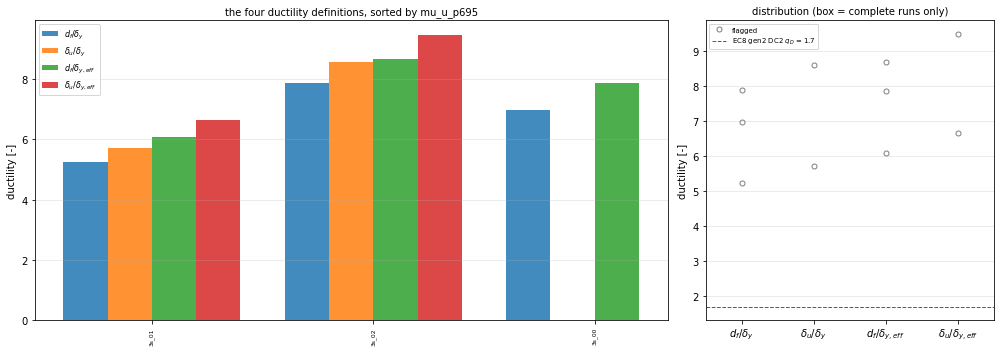

In [13]:
MU_COLS = ["mu_f_bb", "mu_u_bb", "mu_f_p695", "mu_u_p695"]
MU_LABEL = {"mu_f_bb": r"$d_f/\delta_y$", "mu_u_bb": r"$\delta_u/\delta_y$",
            "mu_f_p695": r"$d_f/\delta_{y,eff}$", "mu_u_p695": r"$\delta_u/\delta_{y,eff}$"}
ok = full["cpo_complete"] & full["backbone_fit_ok"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2.2, 1]})

# --- per design, the four side by side ---------------------------------------
order = full.sort_values(DUCTILITY_DEF, na_position="last")["design_group_id"].tolist()
idx = {g: i for i, g in enumerate(order)}
x = np.arange(len(order))
width = 0.2
for k, col in enumerate(MU_COLS):
    vals = full.set_index("design_group_id").loc[order, col].to_numpy(dtype=float)
    axes[0].bar(x + (k - 1.5) * width, vals, width, label=MU_LABEL[col], alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([g.replace("group_", "") for g in order], rotation=90, fontsize=6)
axes[0].set_ylabel("ductility [-]")
axes[0].set_title(f"the four ductility definitions, sorted by {DUCTILITY_DEF}", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis="y")

# --- distributions ------------------------------------------------------------
axes[1].boxplot([full.loc[ok, c].dropna() for c in MU_COLS],
                tick_labels=[MU_LABEL[c] for c in MU_COLS], showmeans=True)
for k, col in enumerate(MU_COLS, start=1):
    bad = full.loc[~ok, col].dropna()
    axes[1].plot(np.full(len(bad), k), bad, "o", mfc="none", mec="0.5", ms=5,
                 label="flagged" if k == 1 else None)
axes[1].axhline(1.7, color="tab:red", ls="--", lw=1, label="EC8 gen2 DC2 $q_D$ = 1.7")
axes[1].set_ylabel("ductility [-]")
axes[1].set_title("distribution (box = complete runs only)", fontsize=10)
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(FIG_PTH / "ductility_definitions_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()

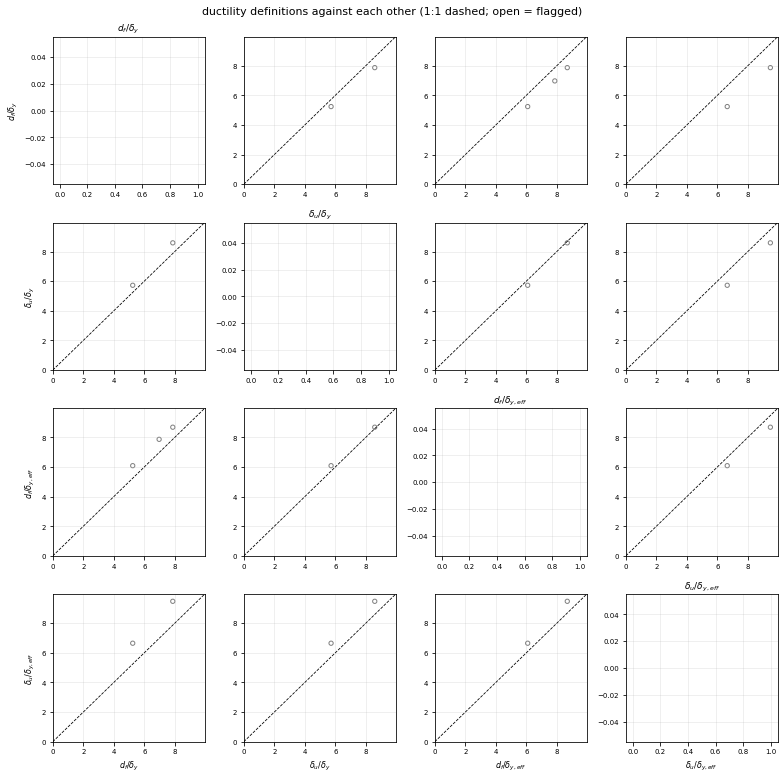

In [14]:
# Pairwise: how far apart are the definitions, design by design?
fig, axes = plt.subplots(len(MU_COLS), len(MU_COLS), figsize=(11, 11))
for i, ci in enumerate(MU_COLS):
    for j, cj in enumerate(MU_COLS):
        ax = axes[i, j]
        if i == j:
            ax.hist(full.loc[ok, ci].dropna(), bins=12, color="tab:blue", alpha=0.75)
            ax.set_title(MU_LABEL[ci], fontsize=9)
        else:
            ax.scatter(full.loc[ok, cj], full.loc[ok, ci], s=18, alpha=0.8)
            ax.scatter(full.loc[~ok, cj], full.loc[~ok, ci], s=18, facecolors="none",
                       edgecolors="0.5")
            lim = [0, np.nanmax(full[MU_COLS].to_numpy(dtype=float)) * 1.05]
            ax.plot(lim, lim, "k--", lw=0.8)
            ax.set_xlim(lim); ax.set_ylim(lim)
        if i == len(MU_COLS) - 1:
            ax.set_xlabel(MU_LABEL[cj], fontsize=8)
        if j == 0:
            ax.set_ylabel(MU_LABEL[ci], fontsize=8)
        ax.grid(alpha=0.25)
        ax.tick_params(labelsize=7)
fig.suptitle("ductility definitions against each other (1:1 dashed; open = flagged)", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_PTH / "ductility_definitions_scatter.png", dpi=DPI, bbox_inches="tight")
plt.show()

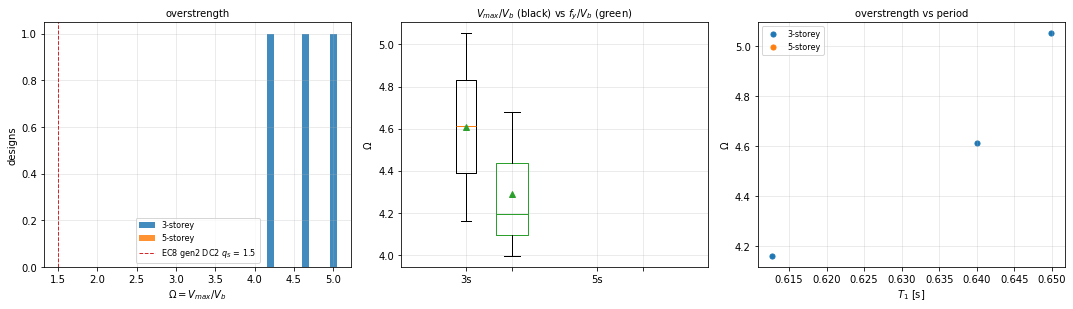

In [15]:
# --- overstrength -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

axes[0].hist([full.loc[full["n_storeys"] == n, "omega_max"].dropna() for n in STOREYS],
             bins=10, stacked=True, label=[f"{n}-storey" for n in STOREYS],
             color=["tab:blue", "tab:orange"], alpha=0.85)
axes[0].axvline(1.5, color="tab:red", ls="--", lw=1, label="EC8 gen2 DC2 $q_S$ = 1.5")
axes[0].set_xlabel(r"$\Omega = V_{max}/V_b$"); axes[0].set_ylabel("designs")
axes[0].set_title("overstrength", fontsize=10); axes[0].legend(fontsize=8)

axes[1].boxplot([full.loc[full["n_storeys"] == n, "omega_max"].dropna() for n in STOREYS],
                tick_labels=[f"{n}s" for n in STOREYS], showmeans=True)
axes[1].boxplot([full.loc[full["n_storeys"] == n, "omega_y"].dropna() for n in STOREYS],
                positions=[1.35, 2.35], widths=0.25,
                tick_labels=["", ""], showmeans=True,
                boxprops=dict(color="tab:green"), medianprops=dict(color="tab:green"))
axes[1].set_ylabel(r"$\Omega$")
axes[1].set_title(r"$V_{max}/V_b$ (black) vs $f_y/V_b$ (green)", fontsize=10)

for n, c in zip(STOREYS, ("tab:blue", "tab:orange")):
    sub = full[full["n_storeys"] == n]
    axes[2].scatter(sub["T1_modal_s"], sub["omega_max"], s=26, color=c, label=f"{n}-storey")
axes[2].set_xlabel("$T_1$ [s]"); axes[2].set_ylabel(r"$\Omega$")
axes[2].set_title(r"overstrength vs period", fontsize=10); axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_PTH / "overstrength_summary.png", dpi=DPI, bbox_inches="tight")
plt.show()

In [16]:
# --- statistics ---------------------------------------------------------------
def summarise(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = frame[cols].describe().T[["count", "mean", "50%", "min", "max", "std"]]
    out = out.rename(columns={"50%": "median"})
    out.insert(len(out.columns), "CoV", out["std"] / out["mean"])
    return out.round(3)


stat_cols = ["omega_max", "omega_y"] + MU_COLS + ["T1_modal_s", "C0"]
print(f"ALL REDUCED DESIGNS (n = {len(full)})")
print(summarise(full, stat_cols).to_string())
print(f"\nCOMPLETE RUNS ONLY (n = {int(ok.sum())})")
print(summarise(full[ok], stat_cols).to_string())
for n in STOREYS:
    sub = full[ok & (full["n_storeys"] == n)]
    if len(sub):
        print(f"\n{n}-STOREY, COMPLETE ONLY (n = {len(sub)})")
        print(summarise(sub, stat_cols).to_string())

ALL REDUCED DESIGNS (n = 3)
            count   mean  median    min    max    std    CoV
omega_max     3.0  4.609   4.614  4.162  5.052  0.445  0.097
omega_y       3.0  4.290   4.193  3.996  4.681  0.353  0.082
mu_f_bb       3.0  6.694   6.973  5.241  7.869  1.336  0.200
mu_u_bb       2.0  7.154   7.154  5.722  8.586  2.025  0.283
mu_f_p695     3.0  7.546   7.866  6.088  8.685  1.327  0.176
mu_u_p695     2.0  8.062   8.062  6.647  9.477  2.001  0.248
T1_modal_s    3.0  0.634   0.640  0.613  0.650  0.019  0.030
C0            3.0  1.260   1.263  1.253  1.264  0.006  0.005

COMPLETE RUNS ONLY (n = 0)
            count  mean  median  min  max  std  CoV
omega_max     0.0   NaN     NaN  NaN  NaN  NaN  NaN
omega_y       0.0   NaN     NaN  NaN  NaN  NaN  NaN
mu_f_bb       0.0   NaN     NaN  NaN  NaN  NaN  NaN
mu_u_bb       0.0   NaN     NaN  NaN  NaN  NaN  NaN
mu_f_p695     0.0   NaN     NaN  NaN  NaN  NaN  NaN
mu_u_p695     0.0   NaN     NaN  NaN  NaN  NaN  NaN
T1_modal_s    0.0   NaN     NaN

## 5. The trimmed frame for nb 072

`design_group_structure_properties.csv`. The filename and the column list are **not free**: nb `072` §8.6
asserts on `PROPS_COLS`, that all 51 design groups are present, and cross-checks `T1_modal_s` against the period
the IDA used. A partial harvest must therefore not be written — nb `072` would assert rather than fall back to
its dummies, which is a worse failure than the dummies.

`delta_y_eff_mm` is written to match whichever `DUCTILITY_DEF` is selected, so that
`ductility == delta_u_mm / delta_y_eff_mm` holds as an identity in the file itself.

In [17]:
PROPS_COLS = ["design_group_id", "T1_modal_s", "V_max_N", "W_N", "Vb_design_N",
              "delta_y_eff_mm", "delta_u_mm", "roof_height_mm", "overstrength", "ductility"]

# The yield displacement each ductility definition divides by; written into
# delta_y_eff_mm so the identity ductility = delta_u / delta_y_eff holds on disk.
YIELD_OF = {"mu_f_bb": "d_y_mm", "mu_u_bb": "d_y_mm",
            "mu_f_p695": "delta_y_eff_mm", "mu_u_p695": "delta_y_eff_mm"}
# ... and the displacement it measures to.
TARGET_OF = {"mu_f_bb": "d_f_mm", "mu_u_bb": "delta_u_mm",
             "mu_f_p695": "d_f_mm", "mu_u_p695": "delta_u_mm"}

props = full[["design_group_id", "T1_modal_s", "V_max_N", "W_N", "Vb_design_N",
              "roof_height_mm"]].copy()
props["delta_y_eff_mm"] = full[YIELD_OF[DUCTILITY_DEF]]
props["delta_u_mm"] = full[TARGET_OF[DUCTILITY_DEF]]
props["overstrength"] = full["omega_max"]          # Fmax/Vb, not Fy/Vb
props["ductility"] = full[DUCTILITY_DEF]
props = props[PROPS_COLS]

# The identity must hold wherever both parts are defined.
defined = props["ductility"].notna()
np.testing.assert_allclose(
    props.loc[defined, "ductility"],
    props.loc[defined, "delta_u_mm"] / props.loc[defined, "delta_y_eff_mm"],
    rtol=1e-12, err_msg="ductility does not equal delta_u / delta_y_eff")

n_nan = int(props["ductility"].isna().sum())
print(f"DUCTILITY_DEF = {DUCTILITY_DEF}  ->  ductility = "
      f"{TARGET_OF[DUCTILITY_DEF]} / {YIELD_OF[DUCTILITY_DEF]}")
print(f"{len(props)} rows, {n_nan} with a NaN ductility")
props.head()

DUCTILITY_DEF = mu_u_p695  ->  ductility = delta_u_mm / delta_y_eff_mm
3 rows, 1 with a NaN ductility


,design_group_id,T1_modal_s,V_max_N,W_N,Vb_design_N,delta_y_eff_mm,delta_u_mm,roof_height_mm,overstrength,ductility
0,group_3s_00,0.649888,441502.798460,3061800.0,87384.868392,19.112909,NaN,10500.0,5.052394,NaN
1,group_3s_01,0.612712,498566.047736,3061800.0,119785.532830,19.202012,127.635278,10500.0,4.162156,6.646974
2,group_3s_02,0.640087,448190.605775,3061800.0,97145.909131,18.671150,176.938858,10500.0,4.613582,9.476591


In [18]:
if len(props) != N_GROUPS_EXPECTED:
    print("#" * 92)
    print(f"# NOT WRITTEN: {PROPS_CSV.name} needs all {N_GROUPS_EXPECTED} design groups, "
          f"have {len(props)}.")
    print("#   nb 072 asserts on the full set, so a partial file would break it rather than")
    print("#   fall back to its dummy values. Attach the analysis drive and re-run.")
    print("#" * 92)
else:
    props.to_csv(PROPS_CSV, index=False)
    print(f"wrote {PROPS_CSV}  ({props.shape[0]} rows x {props.shape[1]} columns)")
    if n_nan:
        print(f"  WARNING: {n_nan} NaN ductilities - nb 072 will propagate them into "
              f"ln_ductility for those designs")

    # nb 072 cross-checks T1_modal_s against the period the IDA used; do it here
    # too so a mismatch surfaces now rather than three notebooks downstream.
    try:
        import re
        frag_dir = Path(cfg["proc_data"]["wp1_sites_fragility_curves"])
        period_re = re.compile(r"period=([0-9.eE+-]+)")
        ida_t1 = {}
        for _, r in full.iterrows():
            site, n = r["representative_site"], r["n_storeys"]
            fp = (frag_dir / f"site_{site}" /
                  f"{n}s_cbf_dc2_site{site}_ida_femap695_collapsefragility_SA.json")
            with open(fp) as f:
                ida_t1[r["design_group_id"]] = float(
                    period_re.search(json.load(f)["intensity_measure"]).group(1))
        rel = (full.set_index("design_group_id")["T1_modal_s"] / pd.Series(ida_t1) - 1).abs()
        print(f"  modal T1 vs IDA T1: max |rel. diff| = {rel.max():.2e}")
    except (FileNotFoundError, AttributeError, KeyError) as exc:
        print(f"  (could not cross-check T1 against the IDA fragilities: {exc})")

############################################################################################
# NOT WRITTEN: design_group_structure_properties.csv needs all 51 design groups, have 3.
#   nb 072 asserts on the full set, so a partial file would break it rather than
#   fall back to its dummy values. Attach the analysis drive and re-run.
############################################################################################


In [19]:
# Column dictionary, as nb 078 writes for its covariates.
DESCRIPTIONS = {
    "design_group_id": ("design group, group_{n}s_{gid:02d}", "-"),
    "T1_modal_s": ("first-mode period from the modal analysis", "s"),
    "V_max_N": ("peak base shear of the cyclic-pushover envelope", "N"),
    "W_N": ("seismic weight of the frame (seismic_mass * 9.81)", "N"),
    "Vb_design_N": ("design base shear of the frame", "N"),
    "delta_y_eff_mm": (f"yield roof displacement used by DUCTILITY_DEF={DUCTILITY_DEF} "
                       f"({YIELD_OF[DUCTILITY_DEF]})", "mm"),
    "delta_u_mm": (f"target roof displacement used by DUCTILITY_DEF={DUCTILITY_DEF} "
                   f"({TARGET_OF[DUCTILITY_DEF]})", "mm"),
    "roof_height_mm": ("roof height", "mm"),
    "overstrength": ("Omega = V_max / Vb_design (FEMA P695 Eq. 6-5)", "-"),
    "ductility": (f"mu = delta_u / delta_y_eff (FEMA P695 Eq. 6-6); "
                  f"definition {DUCTILITY_DEF}", "-"),
}
coldict = pd.DataFrame(
    [{"file": PROPS_CSV.name, "column": c,
      "description": DESCRIPTIONS[c][0], "units": DESCRIPTIONS[c][1]} for c in PROPS_COLS])
coldict.to_csv(COLDICT_CSV, index=False)
print(f"wrote {COLDICT_CSV}")
coldict

wrote C:\Users\clemettn\Documents\phd\data_processed\08_casestudy_structure_datasets\design_group_structure_properties_columns.csv


,file,column,description,units
0,design_group_structure_properties.csv,design_group_id,"design group, group_{n}s_{gid:02d}",-
1,design_group_structure_properties.csv,T1_modal_s,first-mode period from the modal analysis,s
2,design_group_structure_properties.csv,V_max_N,peak base shear of the cyclic-pushover envelope,N
3,design_group_structure_properties.csv,W_N,seismic weight of the frame (seismic_mass * 9.81),N
4,design_group_structure_properties.csv,Vb_design_N,design base shear of the frame,N
5,design_group_structure_properties.csv,delta_y_eff_mm,yield roof displacement used by DUCTILITY_DEF=...,mm
6,design_group_structure_properties.csv,delta_u_mm,target roof displacement used by DUCTILITY_DEF...,mm
7,design_group_structure_properties.csv,roof_height_mm,roof height,mm
8,design_group_structure_properties.csv,overstrength,Omega = V_max / Vb_design (FEMA P695 Eq. 6-5),-
9,design_group_structure_properties.csv,ductility,mu = delta_u / delta_y_eff (FEMA P695 Eq. 6-6)...,-


---

## Appendix — the original brief

The specification this notebook was written from, kept verbatim for reference.

> This notebook should load, postprocess, and save the results of the cyclic pushover (CPO) analyses set up in notebook 55 (notebooks\03_WP1_ground_motion_set\055-setup_pushover_modal_by_design_group.ipynb). The analyses were run on another machine and currently the results are not available, however an example of the data in the folders is in (C:\Users\clemettn\Desktop\test_folder).
> I want the following postprocessing done on the CPO and Modal is results:
> For each structure:
> 1. load the cyclic pushover data
> 2. fit the positive and negative envelope to the data using the fitpo package
> 3. idealise the backbone evelope using the cbf specific method in the fitpo package
> 4. Plot the cpo pushover curve (black), envelope (red-dashes) and idealised backbone curve (blue) and save in \phd\results\08_group_cpo"
> 5. calculate the overstrength ratios F_max / Vb and Fy/Vb from the idealised backbone curve
> 6. calculate the ductility ratio mu_f = dy / df where df is the displacement associated with the start of the steep drop due to brace fracture on the idealised pushover curve. Also do mu = dy / du where du corresponds to a displacement after the peak force is achieved and F = 0.8*Fmax. two different definitions should be considered for dy. first the yield point obtained from the idealised backbone curve. secondly the delta_y_eff definition in eq. 6.7 and 6.8 and described in Appendix B in FEMA P695. The pdf you can find here: "C:\Users\clemettn\OneDrive - Helmut-Schmidt-Universität\The_Oracle\Literature\papers-und-berichte\FEMA P695.pdf"
> 7. load the period from the modal analysis results.
>
> Several CPOs will not have completed the whole displacement trace. Flag where this is the case so that I can manually review the pushover curves plots that you create.
>
> After the calculations create some plots that show a comparison of the different ductility values for each structure
> Also plot the overstrength values and show some statistics. Save all the values in a dataframe in C:\Users\clemettn\Documents\phd\data_processed\08_casestudy_structure_datasets.
>
> Create a dataframe containing only the values that are needed for create the regression dataset in notebook 072 (period, ductility, and overstrength). Make sure that you set it up so that there are is a constant representing the keys of the ductility definition to be included in the analysis so that I can easily just change it. Use only the Fmax/Vb definition of overstrength.